In [10]:
import os
print([f for f in os.listdir(".") if "waimai" in f])

['waimai_10k.csv']


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jieba
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print("✅ 库导入成功")

✅ 库导入成功


In [12]:
df = pd.read_csv("waimai_10k.csv")

print(f"📊 数据集形状: {df.shape[0]} 行, {df.shape[1]} 列")
print("\n列名:", df.columns.tolist())
print("\n前 5 行:")
display(df.head())

print("\n标签分布:")
print(df["label"].value_counts())
print("\n标签比例:")
print(df["label"].value_counts(normalize=True))

📊 数据集形状: 11987 行, 2 列

列名: ['label', 'review']

前 5 行:


,label,review
0,1,很快，好吃，味道足，量大
1,1,没有送水没有送水没有送水
2,1,非常快，态度好。
3,1,方便，快捷，味道可口，快递给力
4,1,菜味道很棒！送餐很及时！



标签分布:
label
0    7987
1    4000
Name: count, dtype: int64

标签比例:
label
0    0.666305
1    0.333695
Name: proportion, dtype: float64


In [13]:
print("=== 负面样本 (label=0) ===")
for i, text in enumerate(df[df["label"]==0]["review"].head(3)):
    print(f"{i+1}. {text}")

print("\n=== 正面样本 (label=1) ===")
for i, text in enumerate(df[df["label"]==1]["review"].head(3)):
    print(f"{i+1}. {text}")

=== 负面样本 (label=0) ===
1. 菜品质量好，味道好，就是百度的问题，总是用运力原因来解释，我也不懂这是什么原因，晚了三个小时呵呵厉害吧！反正订了就退不了，只能干等……
2. 分量还可以……就是有点没特色……下回不吃啦
3. 没什么味道，送来的晚凉了

=== 正面样本 (label=1) ===
1. 很快，好吃，味道足，量大
2. 没有送水没有送水没有送水
3. 非常快，态度好。


In [14]:
test_text = "外卖速度特别快，味道也不错，下次还会点！"
words = jieba.lcut(test_text)
print(f"原文: {test_text}")
print(f"分词: {words}")

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\admin\AppData\Local\Temp\jieba.cache
Loading model cost 0.521 seconds.
Prefix dict has been built successfully.


原文: 外卖速度特别快，味道也不错，下次还会点！
分词: ['外卖', '速度', '特别', '快', '，', '味道', '也', '不错', '，', '下次', '还会点', '！']


In [15]:
# 这个数据集不大，可以直接全量处理
def cut_words(text):
    return " ".join(jieba.lcut(str(text)))

df["cut"] = df["review"].apply(cut_words)

print("分词示例:")
print(f"原文: {df['review'].iloc[0]}")
print(f"分词: {df['cut'].iloc[0]}")

分词示例:
原文: 很快，好吃，味道足，量大
分词: 很快 ， 好吃 ， 味道 足 ， 量 大


In [16]:
X = df["cut"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集: {len(X_train)} 条")
print(f"测试集: {len(X_test)} 条")
print(f"\n训练集负面比例: {(y_train==0).mean():.1%}")
print(f"训练集正面比例: {(y_train==1).mean():.1%}")

训练集: 9589 条
测试集: 2398 条

训练集负面比例: 66.6%
训练集正面比例: 33.4%


In [17]:
vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF 矩阵: {X_train_tfidf.shape}")

TF-IDF 矩阵: (9589, 8000)


In [18]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)

print("=== 朴素贝叶斯 ===")
print(classification_report(y_test, nb_pred, target_names=["负面", "正面"]))

=== 朴素贝叶斯 ===
              precision    recall  f1-score   support

          负面       0.84      0.95      0.89      1598
          正面       0.87      0.65      0.74       800

    accuracy                           0.85      2398
   macro avg       0.86      0.80      0.82      2398
weighted avg       0.85      0.85      0.84      2398



In [19]:
# class_weight='balanced' 让模型更重视少数类（正面评论）
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)
lr_proba = lr.predict_proba(X_test_tfidf)[:, 1]

print("=== 逻辑回归 (class_weight='balanced') ===")
print(classification_report(y_test, lr_pred, target_names=["负面", "正面"]))

=== 逻辑回归 (class_weight='balanced') ===
              precision    recall  f1-score   support

          负面       0.89      0.87      0.88      1598
          正面       0.76      0.79      0.77       800

    accuracy                           0.85      2398
   macro avg       0.82      0.83      0.83      2398
weighted avg       0.85      0.85      0.85      2398



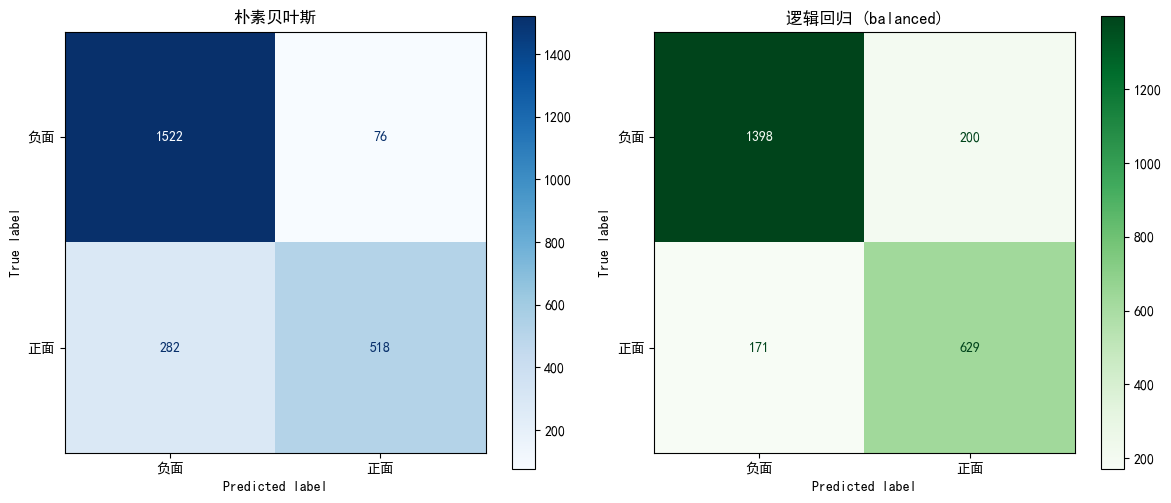

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_nb = confusion_matrix(y_test, nb_pred)
ConfusionMatrixDisplay(cm_nb, display_labels=["负面", "正面"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("朴素贝叶斯")

cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr, display_labels=["负面", "正面"]).plot(ax=axes[1], cmap="Greens")
axes[1].set_title("逻辑回归 (balanced)")

plt.tight_layout()
plt.savefig("01_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

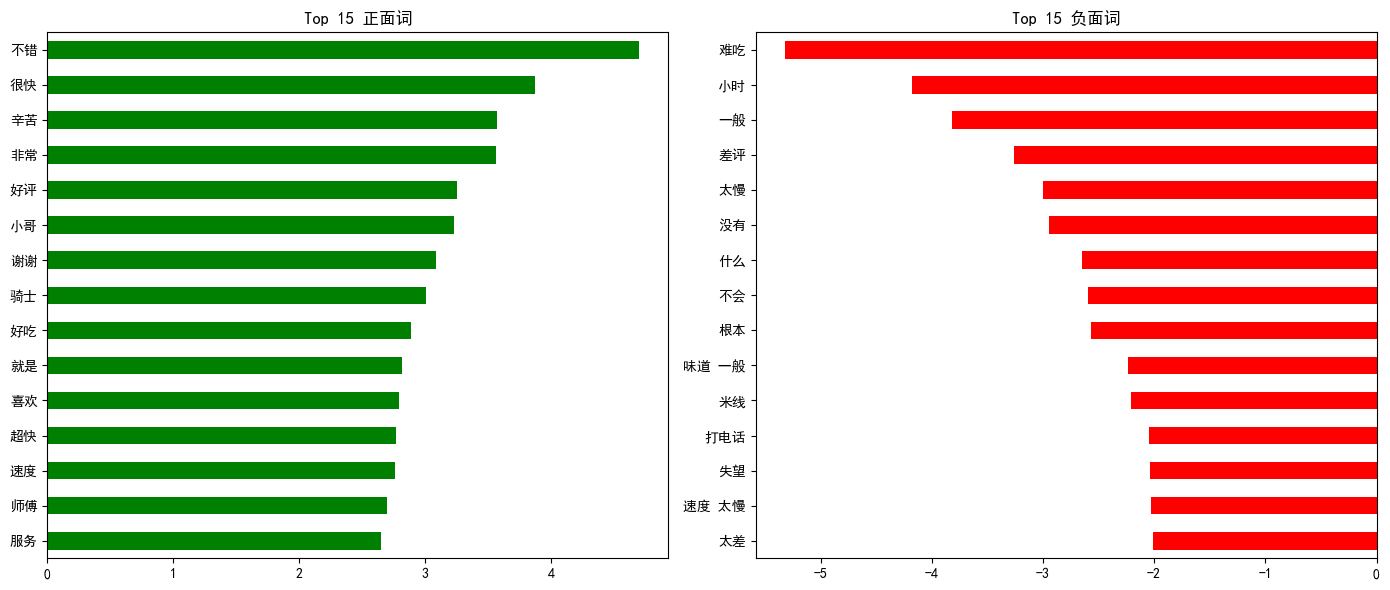

In [21]:
feature_names = vectorizer.get_feature_names_out()
coefs = lr.coef_[0]

# 正面词 Top 15
top_pos = pd.Series(coefs, index=feature_names).nlargest(15)
# 负面词 Top 15
top_neg = pd.Series(coefs, index=feature_names).nsmallest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_pos.sort_values().plot(kind="barh", ax=axes[0], color="green")
axes[0].set_title("Top 15 正面词")
top_neg.sort_values(ascending=False).plot(kind="barh", ax=axes[1], color="red")
axes[1].set_title("Top 15 负面词")

plt.tight_layout()
plt.savefig("02_sentiment_words.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
def predict_sentiment(text):
    cut = " ".join(jieba.lcut(text))
    vec = vectorizer.transform([cut])
    pred = lr.predict(vec)[0]
    proba = lr.predict_proba(vec)[0]
    label = "正面" if pred == 1 else "负面"
    return label, proba[pred]

test_texts = [
    "味道超级棒，配送也很快，五星好评！",
    "等了两个小时才送到，饭都凉了，差评",
    "一般般吧，没什么特别的",
    "分量太少了，根本吃不饱",
    "骑手态度很好，商家包装也很用心"
]

print("=== 外卖评论情感预测 ===")
for text in test_texts:
    label, conf = predict_sentiment(text)
    print(f"{label} ({conf:.1%}) | {text}")

=== 外卖评论情感预测 ===
正面 (95.8%) | 味道超级棒，配送也很快，五星好评！
负面 (97.9%) | 等了两个小时才送到，饭都凉了，差评
负面 (77.2%) | 一般般吧，没什么特别的
负面 (77.6%) | 分量太少了，根本吃不饱
正面 (80.0%) | 骑手态度很好，商家包装也很用心


## 📝 外卖评论情感分析结论

### 1. 数据特点
- 共约 12,000 条外卖评论，其中负面约 8,000 条（67%），正面约 4,000 条（33%）
- **类别不平衡**，负面评论占多数（符合现实：用户更倾向在不满时写评论）

### 2. 处理流程

原始评论文本 →数据加载与探索（12,000条，确认字段和标签分布）→ 数据清洗（检查缺失值、异常短文本） → 中文分词（jieba.lcut，将句子切分为词语序列） → 文本向量化（TF-IDF，保留Top 8000特征，使用unigram+bigram）→ 训练集/测试集划分（8:2分层抽样，保持正负样本比例）→模型训练（逻辑回归 + class_weight='balanced'处理类别不平衡）→模型评估（准确率、精确率、召回率、F1、混淆矩阵） →特征分析（提取高权重正负情感词） →新样本预测（封装预测函数，测试自定义评论）
预测（封装预测函数，测试自定义评论）


### 3. 模型对比
- 逻辑回归 + class_weight='balanced' 能更好地识别正面评论
- 如果不加 balanced，模型可能倾向于全预测为负面（因为负面样本多）

### 4. 关键发现
- **正面关键词**：好吃、速度快、满意、好评、推荐
- **负面关键词**：慢、凉、少、差、难吃、失望
- **外卖特有词**："骑手"、"配送"、"包装"、"分量"等成为重要特征

### 5. 模型局限
- 反讽句识别困难："太好了，好到我都不想吃了" → 可能误判为正面
- 中性评论容易被分到某一类
- 没有考虑评分星级，只有正负标签

### 6. 改进方向
- 加入停用词过滤（"的"、"了"、"是"等无意义词）
- 用 Word2Vec / BERT 替代 TF-IDF
- 尝试 XGBoost / TextCNN